# Install/import libraries

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

# Unzip the dataset

In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon.zip"
extract_path = "/content/drive/MyDrive/AI ML/Data/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Corrected base_dir to point to the extracted content
base_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /content/drive/MyDrive/AI ML/Data/FruitinAmazon/train
Test path: /content/drive/MyDrive/AI ML/Data/FruitinAmazon/test


# Task 1: Data understanding and visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


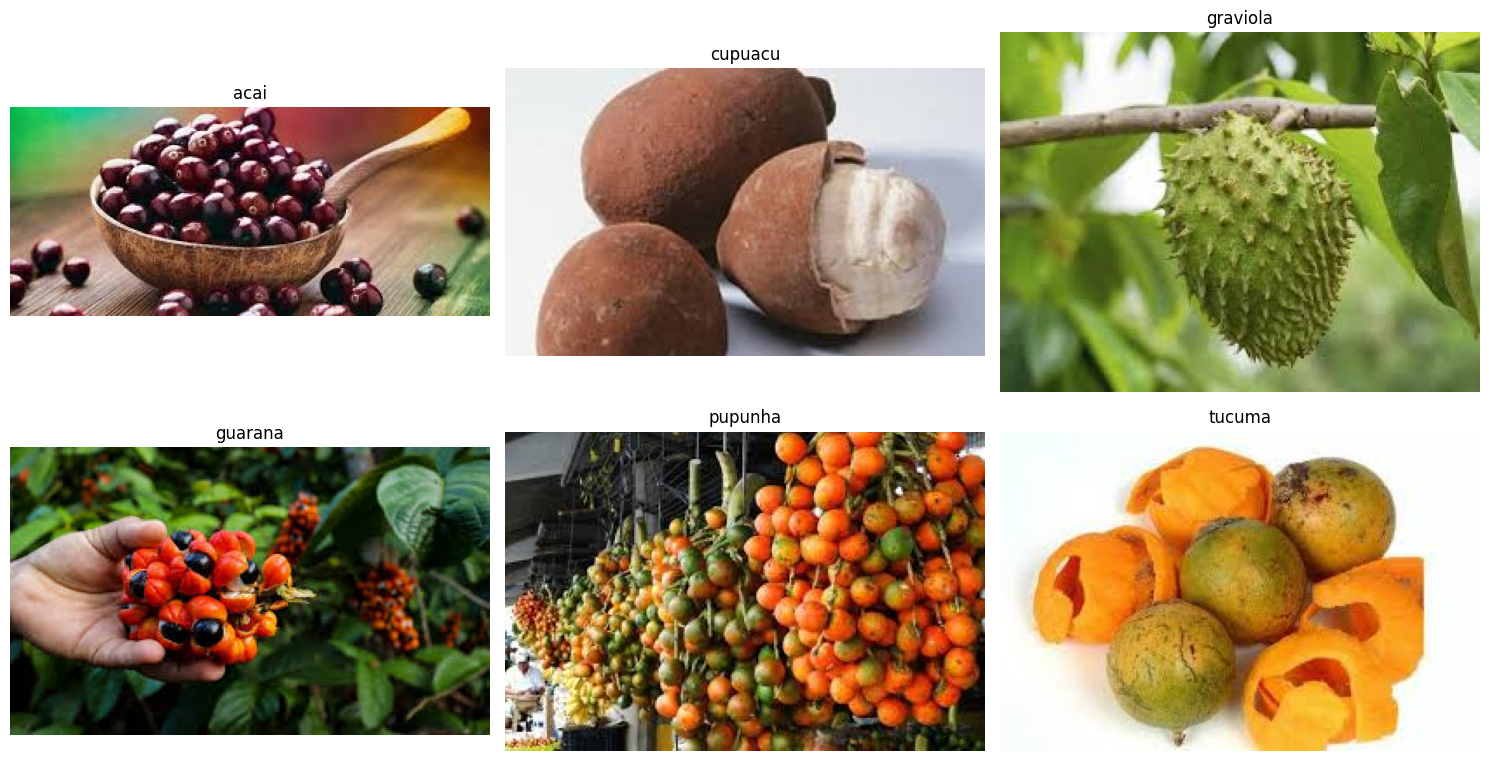

In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image # Make sure PIL.Image is also imported if used directly
import os

class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    chosen = random.choice(images)
    sample_images.append((class_name, os.path.join(class_path, chosen)))

plt.figure(figsize=(15, 8))

for i, (class_name, img_path) in enumerate(sample_images):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Task 1: Check corrupted images

In [6]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# Task 2: Load and preprocess image data

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

--- Verifying raw dataset batch before rescaling ---
  Image batch shape: (16, 128, 128, 3)
  Label batch shape: (16,)
  Image data type: <dtype: 'float32'>
  Image pixel value range (example first image): 0.0579071044921875 - 255.0
  First 5 labels in batch: [1 0 5 4 4]


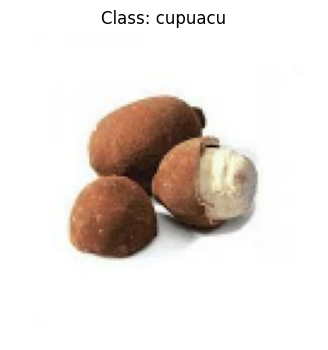

--- End raw dataset verification ---

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [7]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 16   # use 16 because training requirement later says batch size 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

# --- Verification before mapping ---
print("\n--- Verifying raw dataset batch before rescaling ---")
for image_batch, labels_batch in train_ds.take(1):
    print(f"  Image batch shape: {image_batch.shape}")
    print(f"  Label batch shape: {labels_batch.shape}")
    print(f"  Image data type: {image_batch.dtype}")
    print(f"  Image pixel value range (example first image): {image_batch[0].numpy().min()} - {image_batch[0].numpy().max()}")
    print(f"  First 5 labels in batch: {labels_batch.numpy()[:5]}")

    # Display one image to verify (should be 0-255)
    plt.figure(figsize=(4, 4))
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[labels_batch[0].numpy()]}")
    plt.axis("off")
    plt.show()
print("--- End raw dataset verification ---\n")
# --- End Verification before mapping ---

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Task 3: Build the CNN model

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the model

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.1469 - loss: 2.1100
Epoch 1: val_accuracy improved from None to 0.66667, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 380ms/step - accuracy: 0.1667 - loss: 2.1060 - val_accuracy: 0.6667 - val_loss: 1.6844
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.3743 - loss: 1.7842
Epoch 2: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.4028 - loss: 1.7414 - val_accuracy: 0.0000e+00 - val_loss: 1.8890
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.3941 - loss: 1.5348
Epoch 3: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.4028 - loss: 1.5207 - val_accuracy: 0.0556 - val_loss: 1.7128
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5097 - loss: 1.2556
Epoch 4: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.5278 - loss: 1.2202 - val_accuracy: 0.3889 - val_loss: 1.4022
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7319 - l


Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.8056 - loss: 0.8324 - val_accuracy: 0.8889 - val_loss: 0.7600
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.8701 - loss: 0.5747
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.8611 - loss: 0.5511 - val_accuracy: 0.7222 - val_loss: 0.6349
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.7910 - loss: 0.5286
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.8611 - loss: 0.4343 - val_accuracy: 0.6667 - val_loss: 0.6659
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9062 - loss: 0.2417
Epoch 8: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.9167 - loss: 0.2262 - val_accuracy: 0.8889 - val_loss: 0.5198
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9611 - loss:

# Plot training and validation graphs

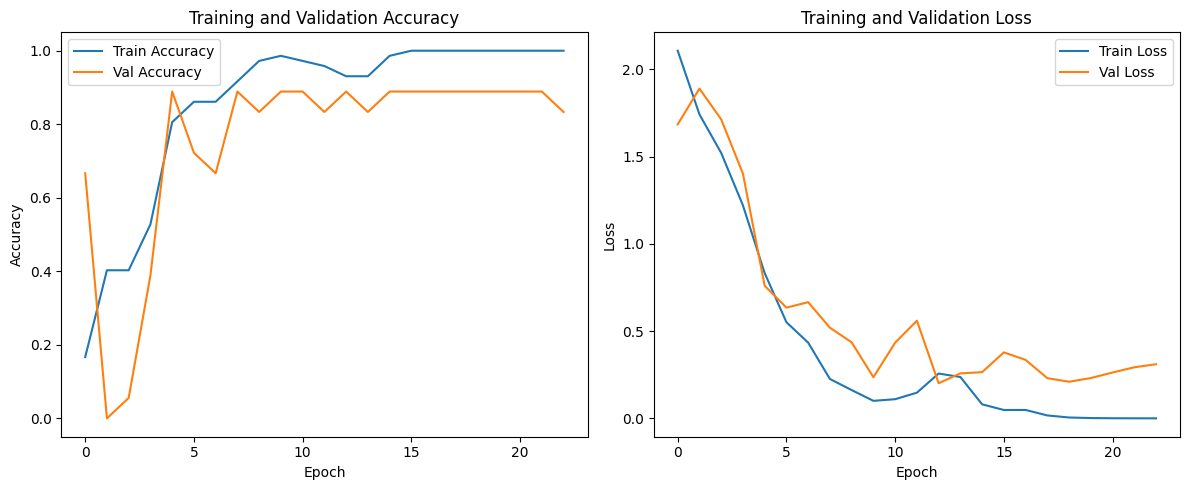

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Task 5: Evaluate on test set

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7667 - loss: 0.6943
Test Loss: 0.6942565441131592
Test Accuracy: 0.7666666507720947


# Task 6: Save and load the model

In [14]:
model.save("fruit_classifier_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [15]:
loaded_model = keras.models.load_model("fruit_classifier_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7667 - loss: 0.6943
Loaded Model Test Loss: 0.6942565441131592
Loaded Model Test Accuracy: 0.7666666507720947


# Task 7: Predictions and classification report

In [16]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1);

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.56      1.00      0.71         5
    graviola       1.00      0.60      0.75         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.60      0.75         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.77        30
   macro avg       0.85      0.77      0.75        30
weighted avg       0.85      0.77      0.75        30

